<a href="https://colab.research.google.com/github/dejuakim/PROJECT_aiffel/blob/master/DeepLearning_%EA%BD%83%EB%B6%84%EB%A5%98_%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1. 데이터셋 내려받기
- tensorflow_datasets 에 포함된 tf_flowers 데이터 사용

### Step 2. 데이터셋을 모델에 넣을 수 있는 형태로 준비하기
- 이미지를 모두 같은 크기로 formatting
- train_batches, validation_batches, test_batches 준비

### Step 3. 모델 설계하기
- class의 갯수가 5가지
- 0 민들레 / 1 데이지 / 2 튤립 / 3 해바라기 / 4 장미
<img width="448" height="197" alt="Image" src="https://github.com/user-attachments/assets/34006c49-241b-4428-bc71-4272fd4b4991" />

### Step 4. 모델 학습시키기
- 여러 가지 옵션 바꿔보기(epoch, learning_rate, optimizer)
- 다른 모델을 base model로 활용
- fc layer의 구성에 변화
- 이전 스텝에서는 시도하지 않았던 Regularization 기법 적용
- Dropout이나 Batch Normalization 적용

#### 1차 학습 후(기본)
- initial loss: 1.68, initial accuracy: 0.26
- EPOCHS = 5, learning_rate = 0.0001, optimmizer = Adam
- accuracy: 0.7634 - loss: 0.7948 - val_accuracy: 0.7466 - val_loss: 0.7389
<img width="752" height="412" alt="Image" src="https://github.com/user-attachments/assets/9b3911b6-566c-493c-a79d-90440f377b7b" />

#### 2차 학습 후(EPOCHS 변경, 콜백 추가)
- initial loss: 0.74, initial accuracy: 0.75
- EPOCHS = 30, EarlyStopping 콜백 추가
- accuracy: 0.8923 - loss: 0.3524 - val_accuracy: 0.8283 - val_loss: 0.4663
<img width="767" height="410" alt="Image" src="https://github.com/user-attachments/assets/c4c6c4b1-20aa-46af-be2a-fa31a4227785" />

#### 3차 학습 후(FC Layer와 Regularization 적용)
- initial loss: 0.47, initial accuracy: 0.83
- batch_norm_layer와 dropout_layer 추가
- accuracy: 0.8884 - loss: 0.3152 - val_accuracy: 0.8420 - val_loss: 0.6133

#### 4차 학습 후(dense_layer 가중치 규제 추가)
- EPOCHS = 40
- accuracy: 0.9240 - loss: 0.4461 - val_accuracy: 0.8529 - val_loss: 0.6561

#### 5차 학습 후(콜백 추가)
- accuracy: 0.9374 - loss: 0.3975 - val_accuracy: 0.8474 - val_loss: 0.6422
<img width="762" height="409" alt="Image" src="https://github.com/user-attachments/assets/7cc5caba-6f1e-4f3b-b2bd-b0e5c7680019" />
> 모델 과적합 확인

#### 6차 학습 후
<img width="760" height="402" alt="Image" src="https://github.com/user-attachments/assets/f4615f6e-5ecf-4d4e-a929-55f12feae4d0" />

### Step 5. 모델 성능 평가하기
- 모델이 학습된 과정을 그래프로도 그려보기
- validation_batches나 test_batches에 있는 데이터에 대한 예측 결과 확인

### Step 6. 모델 활용하기
-  원하는 이미지를 자유롭게 모델에 입력해보기
- 어떤 예측 결과 확인

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [ ]:

(raw_train, raw_validation, raw_test), metadata = tfds.load(
    name='tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    data_dir='./content',
    download=True,
    with_info=True,
    as_supervised=True,
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling content/tf_flowers/incomplete.WSDPE3_3.0.1/tf_flowers-train.tfrecord*...:   0%|          | 0/3670 [0…

Dataset tf_flowers downloaded and prepared to content/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [ ]:
IMG_SIZE = 160 # 리사이징할 이미지의 크기

def format_example(image, label):
    image = tf.cast(image, tf.float32)  # image=float(image)같은 타입캐스팅의  텐서플로우 버전입니다.
    image = (image/127.5) - 1 # 픽셀값의 scale 수정
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train = raw_train.map(format_example)
validation = raw_validation.map(format_example)
test = raw_test.map(format_example)

In [ ]:
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 1000

train_batches = train.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE)
validation_batches = validation.batch(BATCH_SIZE)
test_batches = test.batch(BATCH_SIZE)

In [ ]:
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# Create the base model from the pre-trained model VGG16
base_model = tf.keras.applications.VGG16(input_shape=IMG_SHAPE,
                                         include_top=False,
                                         weights='imagenet')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for image_batch, label_batch in train_batches.take(1):
    break

image_batch.shape, label_batch.shape

(TensorShape([32, 160, 160, 3]), TensorShape([32]))

In [ ]:
feature_batch = base_model(image_batch)
feature_batch.shape

TensorShape([32, 5, 5, 512])

In [ ]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

In [ ]:
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 512)


In [ ]:
# 활성화 함수 ReLU 사용
dense_layer = tf.keras.layers.Dense(units=256,
                                    activation='relu')
# unit은 label class가 5개이므로 5로 설정
# 활성화 함수는 Softmax를 사용합니다.
prediction_layer = tf.keras.layers.Dense(units=5,
                                         activation='softmax')
prediction_batch = prediction_layer(dense_layer(feature_batch_average))
print(prediction_batch.shape)

(32, 5)


In [ ]:
base_model.trainable = False

In [ ]:
model = tf.keras.Sequential([
  base_model,
  global_average_layer,
  dense_layer,
  prediction_layer
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,301 (56.64 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,            # 성능 개선이 없는 상태로 3번의 에포크가 지나면 멈춤
    restore_best_weights=True  # 학습 종료 후 가장 성능이 좋았던 때의 가중치로 되돌림
)

base_learning_rate = 0.0001
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
validation_steps=20
loss0, accuracy0 = model.evaluate(validation_batches, steps = validation_steps)

print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.7511 - loss: 0.7363 
initial loss: 0.74
initial accuracy: 0.75


In [ ]:
EPOCHS = 30

history = model.fit(train_batches,
                    epochs=EPOCHS,
                    validation_data=validation_batches,
                    callbacks=[early_stopping])

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 136ms/step - accuracy: 0.7747 - loss: 0.7299 - val_accuracy: 0.7520 - val_loss: 0.6902
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.8049 - loss: 0.6740 - val_accuracy: 0.7766 - val_loss: 0.6683
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.8032 - loss: 0.6250 - val_accuracy: 0.7738 - val_loss: 0.6490
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 145ms/step - accuracy: 0.8248 - loss: 0.5956 - val_accuracy: 0.7766 - val_loss: 0.6109
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.8247 - loss: 0.5721 - val_accuracy: 0.7929 - val_loss: 0.5924
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.8318 - loss: 0.5581 - val_accuracy: 0.7956 - val_loss: 0.5781
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.8304 - loss: 0.5462 - val_accuracy: 0.7929 - val_loss: 0.5704
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.8425 - loss: 0.5193 - val_accu

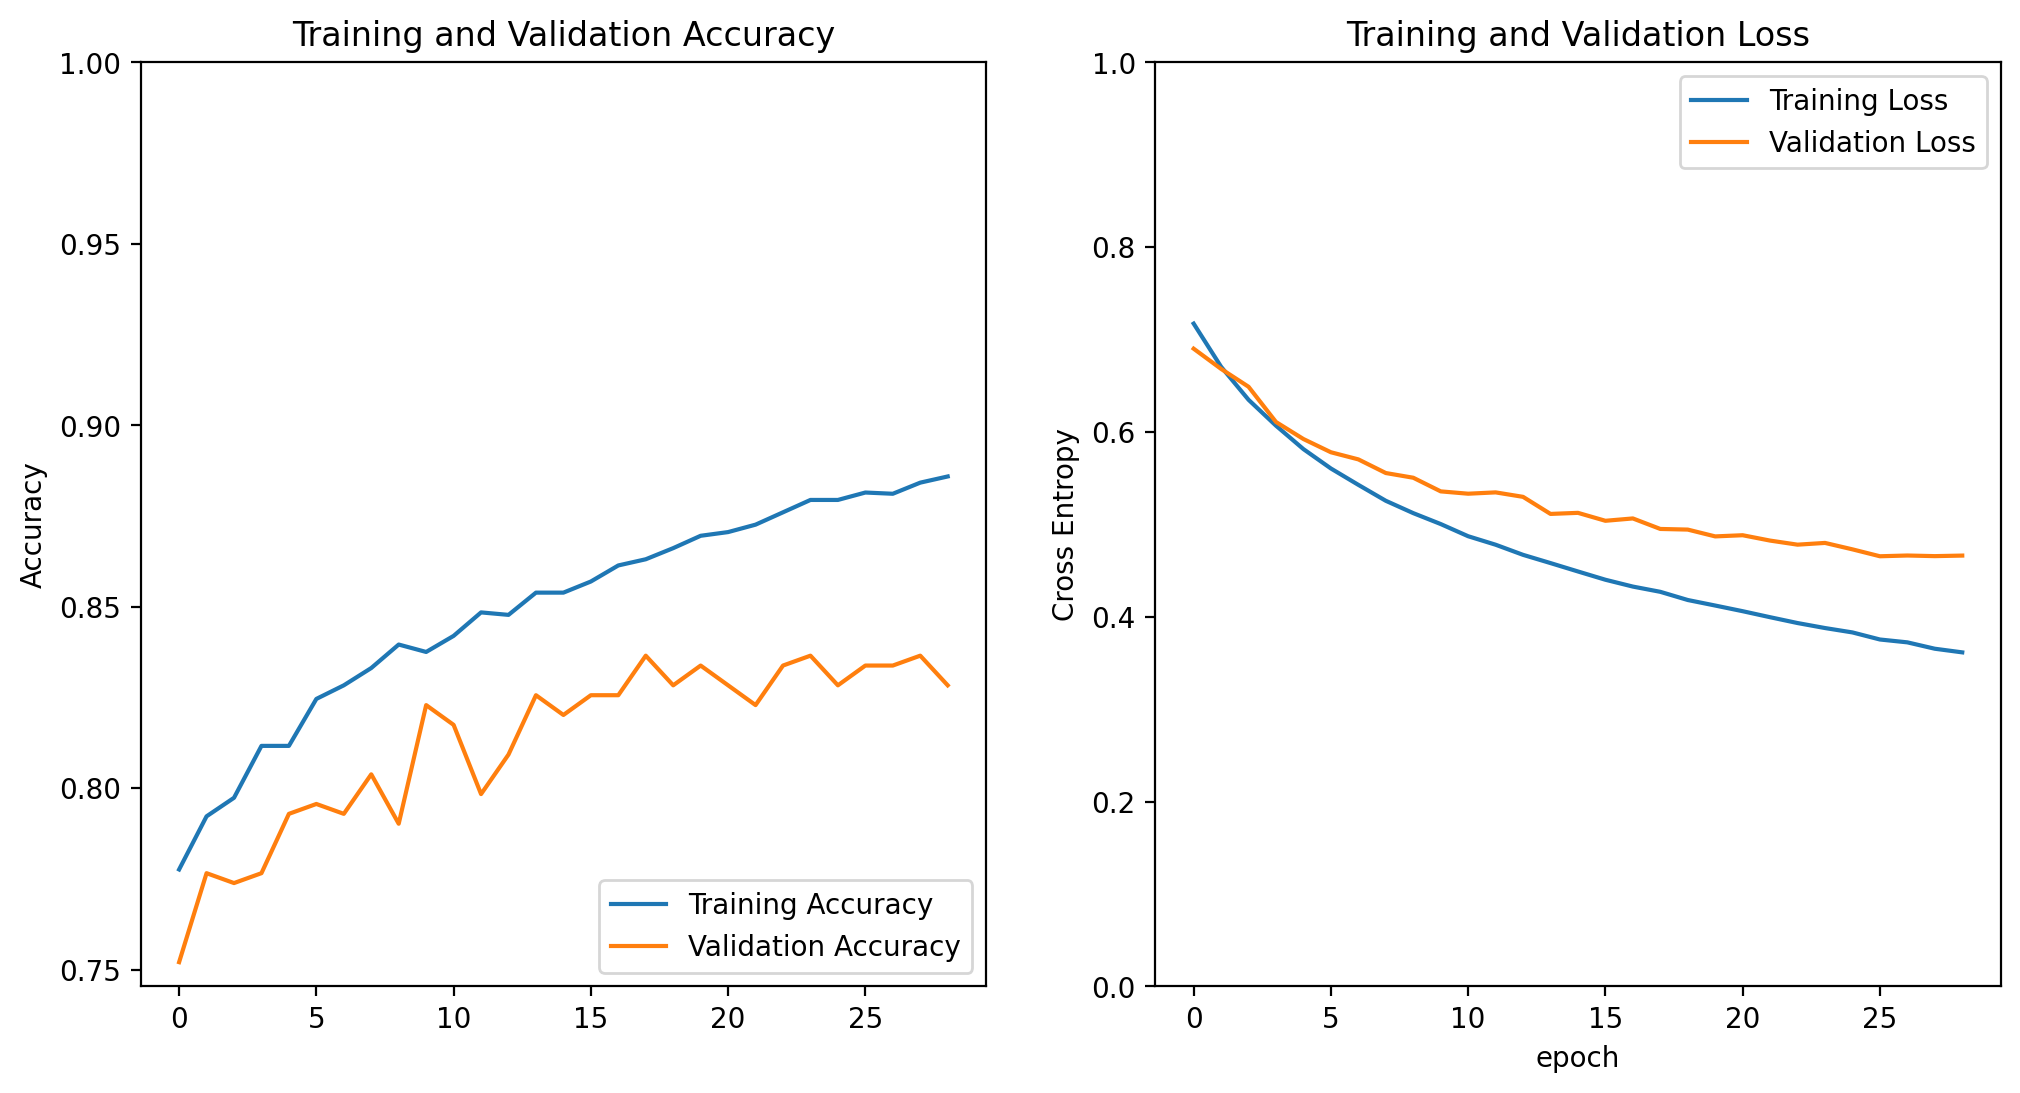

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
for image_batch, label_batch in test_batches.take(1):
    images = image_batch
    labels = label_batch
    predictions = model.predict(image_batch)
    pass

predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step


array([[8.83458368e-03, 2.50141397e-02, 8.66561294e-01, 1.38462493e-02,
        8.57437626e-02],
       [9.99751389e-01, 2.32875362e-04, 9.14808368e-07, 3.36862377e-06,
        1.14083578e-05],
       [7.47725248e-01, 1.04961686e-01, 2.44262386e-02, 1.04531318e-01,
        1.83555614e-02],
       [1.05231907e-03, 4.53713723e-03, 6.62621498e-01, 2.25442392e-03,
        3.29534590e-01],
       [6.99549079e-01, 2.59767950e-01, 1.25999786e-02, 9.55962762e-03,
        1.85233988e-02],
       [9.55555618e-01, 2.84705572e-02, 2.56739021e-03, 1.28433313e-02,
        5.62917849e-04],
       [5.31575130e-03, 4.88877483e-03, 9.28131759e-01, 3.49719897e-02,
        2.66916845e-02],
       [4.60409731e-01, 4.73897696e-01, 7.01931654e-04, 6.30333051e-02,
        1.95742468e-03],
       [3.24759749e-03, 4.63619275e-04, 1.93872824e-02, 9.28615570e-01,
        4.82858941e-02],
       [9.99570310e-01, 4.17611591e-04, 5.02734792e-07, 1.07278274e-05,
        8.05595164e-07],
       [9.76215482e-01, 2.1105

In [ ]:
import numpy as np
predictions = np.argmax(predictions, axis=1)
predictions

array([2, 0, 0, 2, 0, 0, 2, 1, 3, 0, 0, 0, 3, 4, 0, 3, 2, 0, 2, 4, 2, 0,
       2, 0, 1, 3, 2, 4, 4, 3, 0, 4])

In [ ]:
plt.figure(figsize=(20, 12))

for idx, (image, label, prediction) in enumerate(zip(images, labels, predictions)):
    plt.subplot(4, 8, idx+1)
    image = (image + 1) / 2
    plt.imshow(image)
    correct = label == prediction
    title = f'real: {label} / pred :{prediction}\n {correct}!'
    if not correct:
        plt.title(title, fontdict={'color': 'red'})
    else:
        plt.title(title, fontdict={'color': 'blue'})
    plt.axis('off')

In [ ]:
count = 0
for image, label, prediction in zip(images, labels, predictions):
    correct = label == prediction
    if correct:
        count = count + 1

print(count / 32 * 100)

93.75


### 3차 - batch_norm_layer와 dropout_layer 추가

In [ ]:
# 추가할 레이어 정의
batch_norm_layer = tf.keras.layers.BatchNormalization()
dropout_layer = tf.keras.layers.Dropout(0.2)

In [ ]:
# 모델 구성 변경
model = tf.keras.Sequential([
  base_model,
  global_average_layer,
  dense_layer,
  batch_norm_layer,  # 성능 안정화를 위한 배치 정규화 추가
  dropout_layer,     # 과적합 방지를 위한 드롭아웃 추가
  prediction_layer
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,325 (56.64 MB)

 Trainable params: 133,125 (520.02 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,            # 성능 개선이 없는 상태로 7번의 에포크가 지나면 멈춤
    restore_best_weights=True  # 학습 종료 후 가장 성능이 좋았던 때의 가중치로 되돌림
)

base_learning_rate = 0.0001
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
validation_steps=20
loss0, accuracy0 = model.evaluate(validation_batches, steps = validation_steps)

print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.8309 - loss: 0.4545
initial loss: 0.47
initial accuracy: 0.83


In [ ]:
EPOCHS = 40

history = model.fit(train_batches,
                    epochs=EPOCHS,
                    validation_data=validation_batches,
                    callbacks=[early_stopping])

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accuracy: 0.8743 - loss: 0.5036 - val_accuracy: 0.8338 - val_loss: 0.4650
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.8831 - loss: 0.4434 - val_accuracy: 0.8311 - val_loss: 0.5103
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.8817 - loss: 0.4106 - val_accuracy: 0.8392 - val_loss: 0.5643
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.8881 - loss: 0.4021 - val_accuracy: 0.8392 - val_loss: 0.6128
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.8949 - loss: 0.3514 - val_accuracy: 0.8311 - val_loss: 0.6287
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.8960 - loss: 0.3386 - val_accuracy: 0.8338 - val_loss: 0.6386
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - accuracy: 0.8988 - loss: 0.3049 - val_accuracy: 0.8501 - val_loss: 0.6288
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 139ms/step - accuracy: 0.8884 - loss: 0.3152 - val_accu

### 4차 - dense_layer 정의 수정(가중치 규제 추가)

In [ ]:
# 가중치 규제 추가
dense_layer = tf.keras.layers.Dense(units=256,
                                    activation='relu',
                                    kernel_regularizer=tf.keras.regularizers.l2(0.001))

model = tf.keras.Sequential([
  base_model,
  global_average_layer,
  dense_layer,       # 위에서 수정한 레이어가 들어갑니다.
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Dropout(0.2),
  prediction_layer
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
EPOCHS = 30

history = model.fit(train_batches,
                    epochs=EPOCHS,
                    validation_data=validation_batches,
                    callbacks=[early_stopping])

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 167ms/step - accuracy: 0.3327 - loss: 2.1562 - val_accuracy: 0.6431 - val_loss: 1.5168
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.6193 - loss: 1.3156 - val_accuracy: 0.7275 - val_loss: 1.2320
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.7152 - loss: 1.0659 - val_accuracy: 0.7520 - val_loss: 1.0251
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.7503 - loss: 0.9568 - val_accuracy: 0.7766 - val_loss: 0.9042
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.7783 - loss: 0.8873 - val_accuracy: 0.7820 - val_loss: 0.8443
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.8014 - loss: 0.8353 - val_accuracy: 0.7793 - val_loss: 0.8121
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.8113 - loss: 0.7874 - val_accuracy: 0.7929 - val_loss: 0.7907
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - accuracy: 0.8356 - loss: 0.7389 - val_accu

### 5차 - 학습률을 스스로 조절하는 ReduceLROnPlateau 콜백 추가

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

In [ ]:
EPOCHS = 40
history = model.fit(train_batches,
                    epochs=EPOCHS,
                    validation_data=validation_batches,
                    callbacks=[early_stopping, reduce_lr])

Epoch 1/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.9104 - loss: 0.4771 - val_accuracy: 0.8420 - val_loss: 0.6570 - learning_rate: 1.0000e-04
Epoch 2/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.9226 - loss: 0.4462 - val_accuracy: 0.8529 - val_loss: 0.6565 - learning_rate: 1.0000e-04
Epoch 3/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - accuracy: 0.9222 - loss: 0.4429 - val_accuracy: 0.8529 - val_loss: 0.6494 - learning_rate: 1.0000e-04
Epoch 4/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - accuracy: 0.9183 - loss: 0.4496 - val_accuracy: 0.8447 - val_loss: 0.6517 - learning_rate: 1.0000e-04
Epoch 5/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - accuracy: 0.9230 - loss: 0.4432 - val_accuracy: 0.8474 - val_loss: 0.6515 - learning_rate: 1.0000e-04
Epoch 6/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.9396 - loss: 0.4006 - val_accuracy: 0.8501 - val_loss: 0.6503 - learning_rate: 2.0000e-05
Epoch 7/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - acc

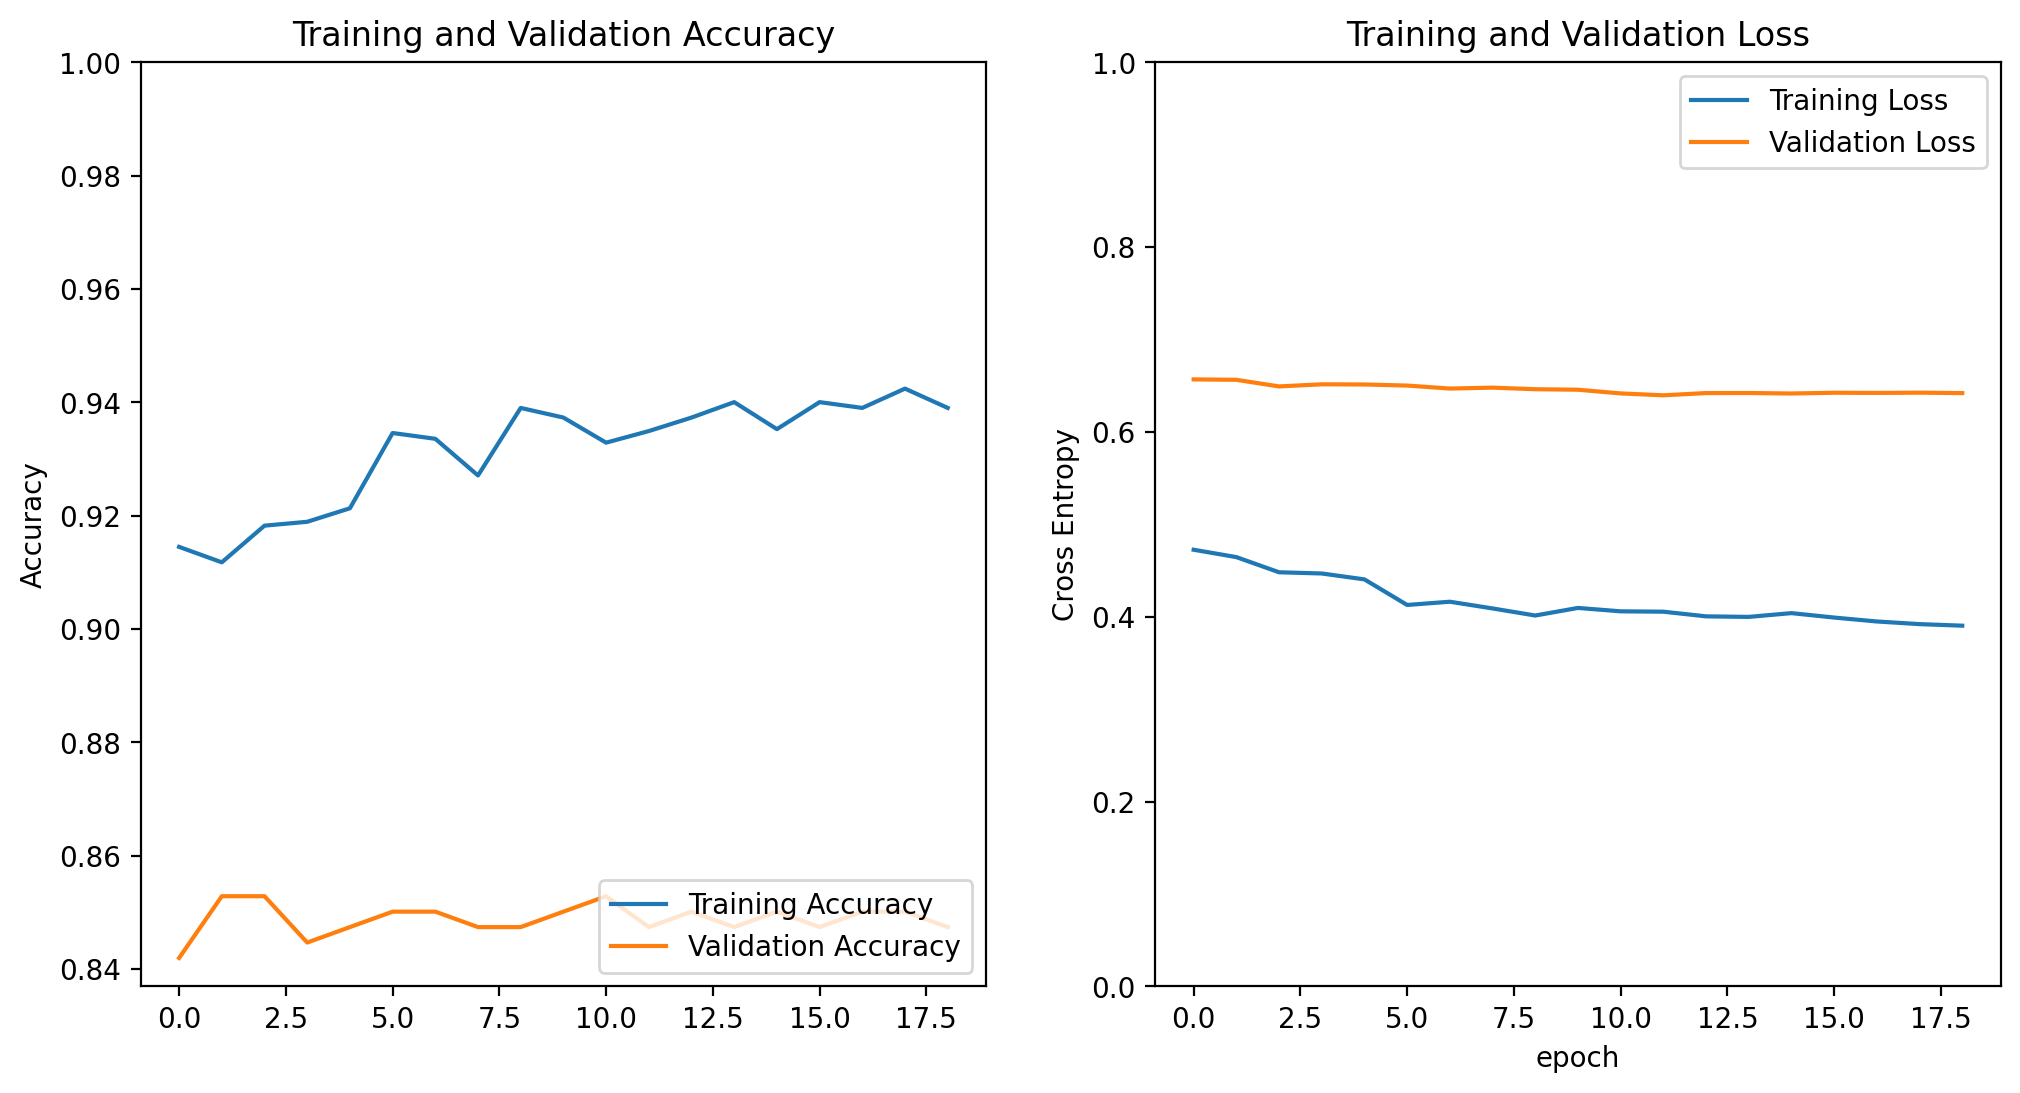

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

### 데이터 증강 시도

In [ ]:
# 레이어 정의
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"), # 좌우/상하 반전
  tf.keras.layers.RandomRotation(0.2), # 무작위 회전
  tf.keras.layers.RandomZoom(0.2),     # 무작위 확대/축소
])

# 모델 재구성
model = tf.keras.Sequential([
  data_augmentation,      # <--- 레이어 추가
  base_model,
  global_average_layer,
  dense_layer,
  tf.keras.layers.Dropout(0.3),
  prediction_layer
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
EPOCHS = 40
history = model.fit(train_batches,
                    epochs=EPOCHS,
                    validation_data=validation_batches,
                    callbacks=[early_stopping, reduce_lr])

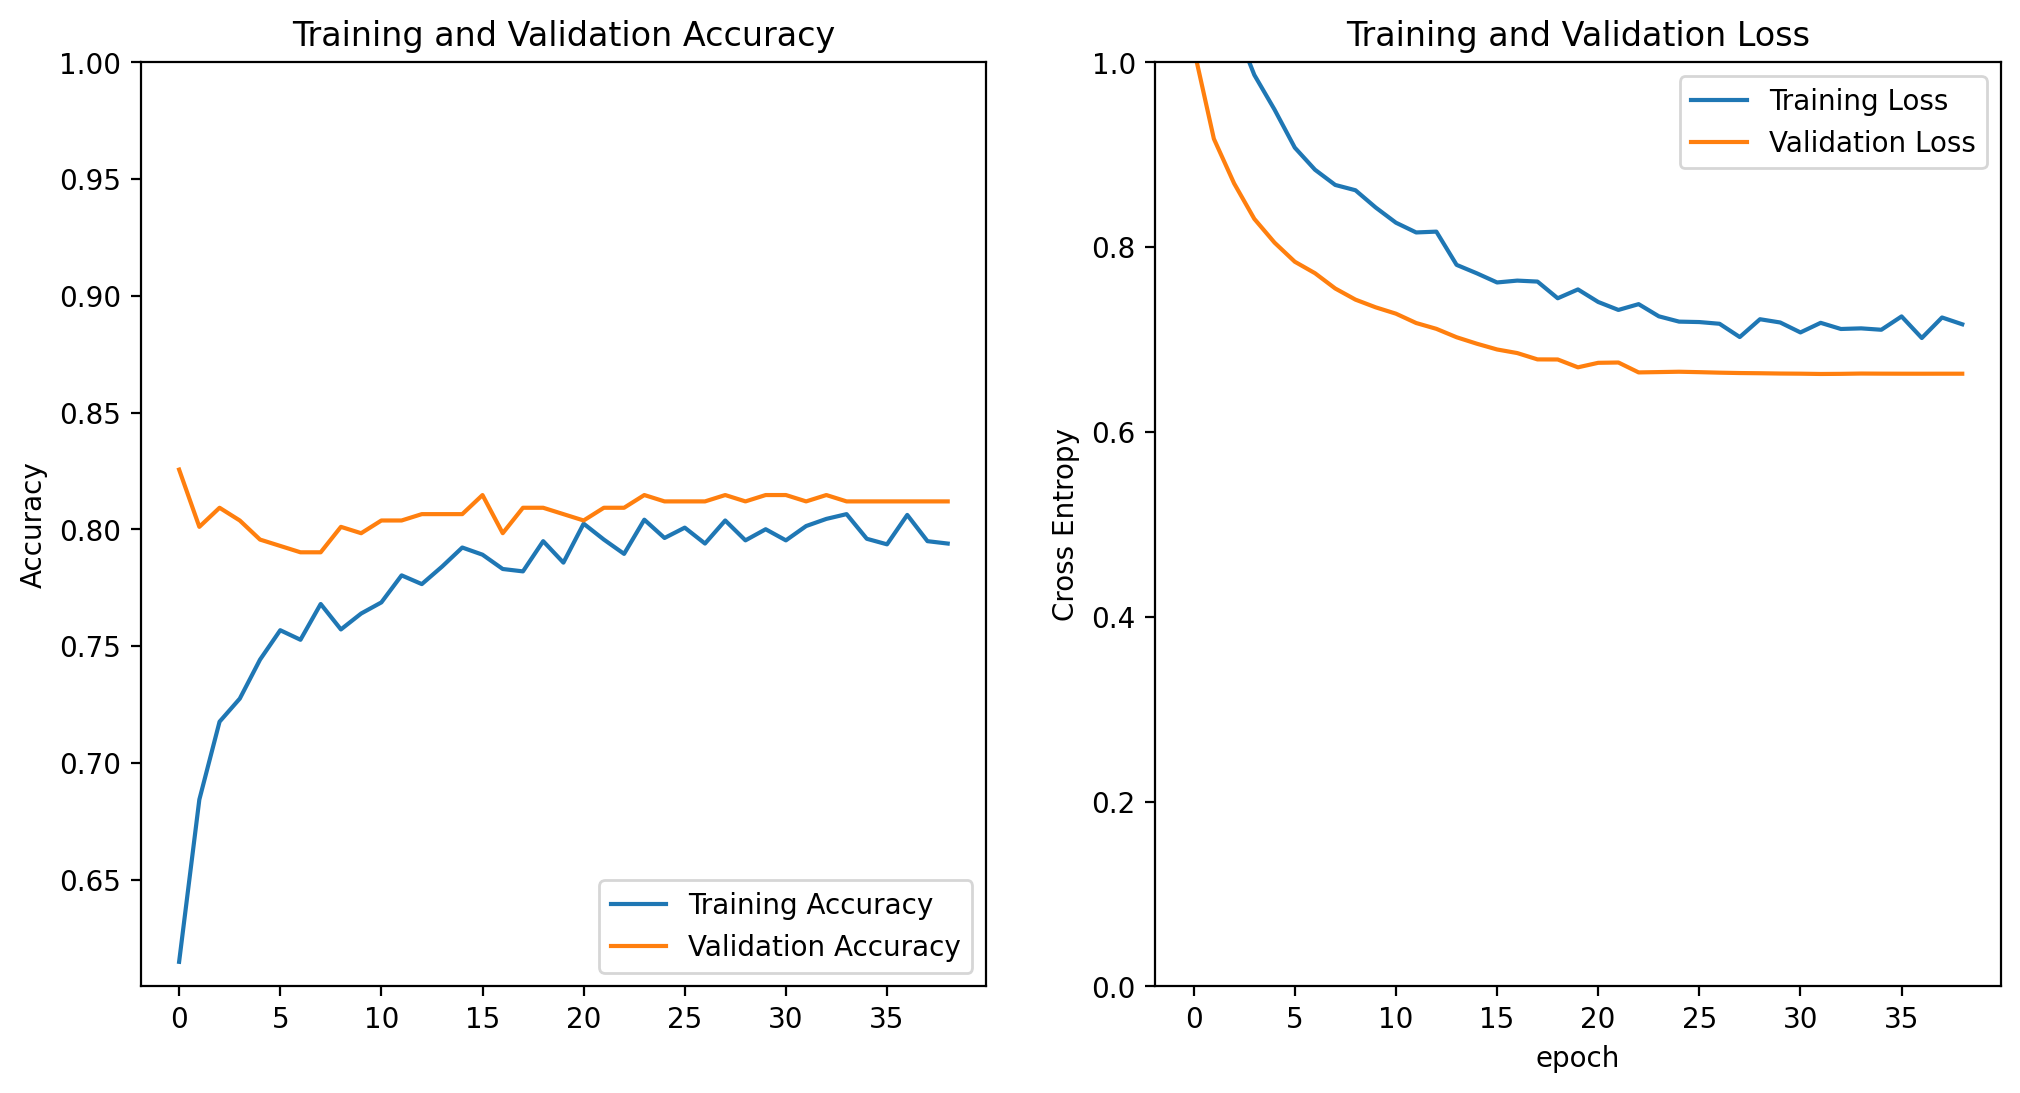

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
# 활성화 함수 ReLU 사용
dense_layer = tf.keras.layers.Dense(units=256,
                                    activation='relu',
                                    kernel_regularizer=tf.keras.regularizers.l2(0.001)
)
# unit은 label class가 5개이므로 5로 설정
# 활성화 함수는 Softmax를 사용합니다.
prediction_layer = tf.keras.layers.Dense(units=5,
                                         activation='softmax')
prediction_batch = prediction_layer(dense_layer(feature_batch_average))
print(prediction_batch.shape)

(32, 5)


In [ ]:
batch_norm_layer = tf.keras.layers.BatchNormalization()
dropout_layer = tf.keras.layers.Dropout(0.2)

model = tf.keras.Sequential([
  base_model,
  global_average_layer,
  dense_layer,
  batch_norm_layer,  # 성능 안정화를 위한 배치 정규화 추가
  dropout_layer,     # 과적합 방지를 위한 드롭아웃 추가
  prediction_layer
])

In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,325 (56.64 MB)

 Trainable params: 133,125 (520.02 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [ ]:
base_model.trainable = False

In [ ]:
base_learning_rate = 0.0001
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
validation_steps=20
loss0, accuracy0 = model.evaluate(validation_batches, steps = validation_steps)

print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.7921 - loss: 0.8080 
initial loss: 0.79
initial accuracy: 0.80


In [ ]:
EPOCHS = 10
history = model.fit(train_batches,
                    epochs=EPOCHS,
                    validation_data=validation_batches)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 151ms/step - accuracy: 0.8546 - loss: 0.6757 - val_accuracy: 0.8202 - val_loss: 0.7512
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 139ms/step - accuracy: 0.8526 - loss: 0.6688 - val_accuracy: 0.8229 - val_loss: 0.7340
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - accuracy: 0.8660 - loss: 0.6200 - val_accuracy: 0.8202 - val_loss: 0.7224
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.8711 - loss: 0.5864 - val_accuracy: 0.8202 - val_loss: 0.6976
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.8777 - loss: 0.5844 - val_accuracy: 0.8093 - val_loss: 0.7577
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step - accuracy: 0.8760 - loss: 0.5720 - val_accuracy: 0.8338 - val_loss: 0.6896
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - accuracy: 0.8888 - loss: 0.5503 - val_accuracy: 0.8365 - val_loss: 0.6792
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.9011 - loss: 0.5200 - val_accu

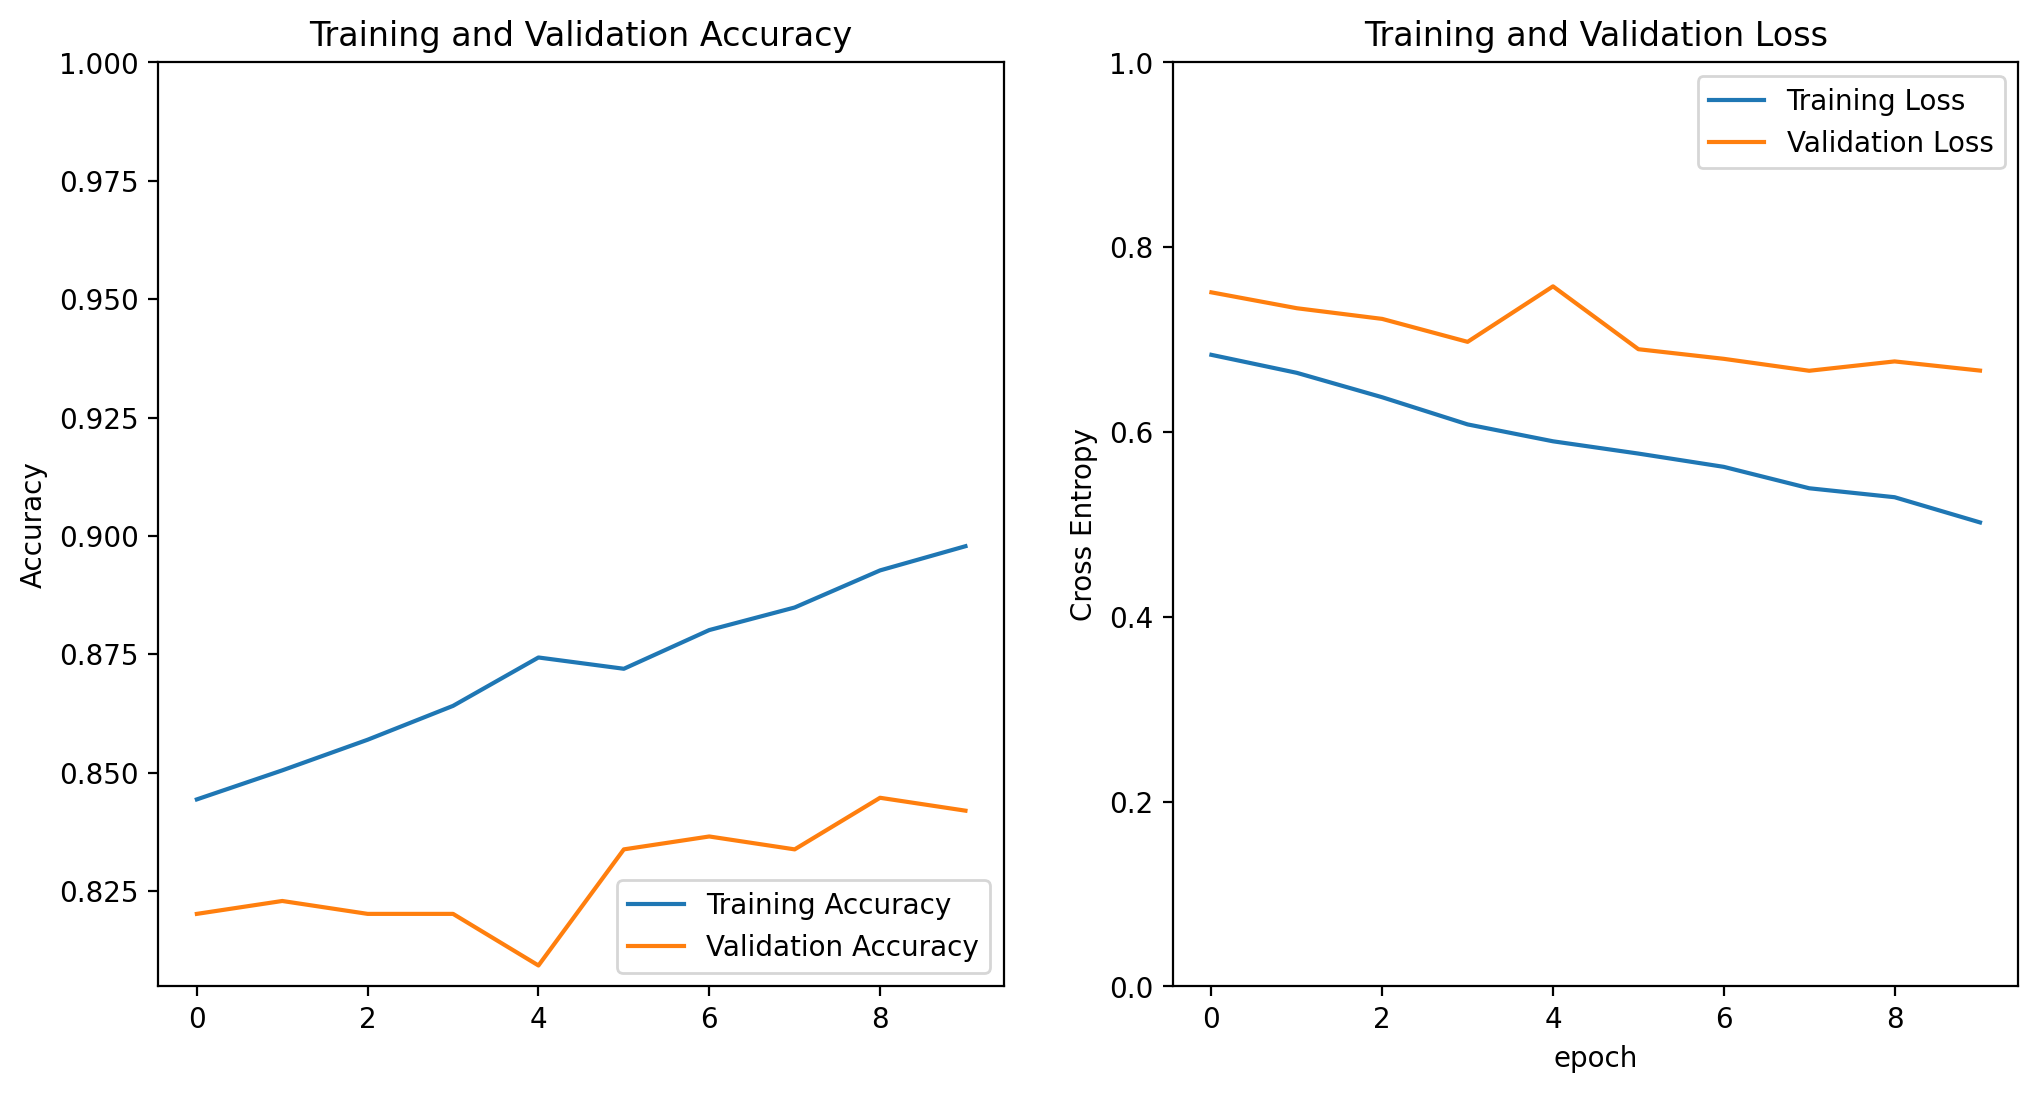

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = True # 전체 잠금 해제

# 뒤에서 40번째 레이어까지만 남기고 앞부분(Early & Middle)은 다시 얼림
for layer in base_model.layers[:-40]:
  layer.trainable = False

In [ ]:
# 활성화 함수 ReLU 사용
dense_layer = tf.keras.layers.Dense(units=256,
                                    activation='relu')
# unit은 label class가 5개이므로 5로 설정
# 활성화 함수는 Softmax를 사용합니다.
prediction_layer = tf.keras.layers.Dense(units=5,
                                         activation='softmax')
prediction_batch = prediction_layer(dense_layer(feature_batch_average))
print(prediction_batch.shape)

(32, 5)


In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,114,577 (57.66 MB)

 Trainable params: 133,125 (520.02 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

 Optimizer params: 266,252 (1.02 MB)

In [ ]:
batch_norm_layer = tf.keras.layers.BatchNormalization()
dropout_layer = tf.keras.layers.Dropout(0.2)

model = tf.keras.Sequential([
  base_model,
  global_average_layer,
  dense_layer,
  batch_norm_layer,  # 성능 안정화를 위한 배치 정규화 추가
  dropout_layer,     # 과적합 방지를 위한 드롭아웃 추가
  prediction_layer
])

In [ ]:
# Base Model 불러오기 (EfficientNetB0)
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # 1차 학습을 위해 얼려둡니다.

# 레이어 정의
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
dense_layer = tf.keras.layers.Dense(units=256, activation='relu')
prediction_layer = tf.keras.layers.Dense(units=5, activation='softmax')

# 3. 모델 조립
model = tf.keras.Sequential([
  base_model,
  global_average_layer,
  dense_layer,
  prediction_layer
])

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,792 (16.70 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
base_learning_rate = 0.0001
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
validation_steps=20
loss0, accuracy0 = model.evaluate(validation_batches, steps = validation_steps)

print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 290ms/step - accuracy: 0.1874 - loss: 1.6968
initial loss: 1.72
initial accuracy: 0.17


In [ ]:
EPOCHS = 10
history = model.fit(train_batches,
                    epochs=EPOCHS,
                    validation_data=validation_batches)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 145ms/step - accuracy: 0.2443 - loss: 1.6139 - val_accuracy: 0.2807 - val_loss: 1.5947
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.2850 - loss: 1.5938 - val_accuracy: 0.2725 - val_loss: 1.5880
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.2879 - loss: 1.5841 - val_accuracy: 0.3025 - val_loss: 1.5783
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.2874 - loss: 1.5808 - val_accuracy: 0.2698 - val_loss: 1.5850
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3042 - loss: 1.5701 - val_accuracy: 0.3924 - val_loss: 1.5507
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.3038 - loss: 1.5754 - val_accuracy: 0.3215 - val_loss: 1.5640
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.2934 - loss: 1.5737 - val_accuracy: 0.3161 - val_loss: 1.5391
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3145 - loss: 1.5530 - val_accuracy: 0.3651 -

## 회고
---
- 1차 이슈
  
  컴퓨터 성능 문제인지 시간이 너무 오래 걸림

  EPOCHS = 5 로 20분 넘게 실행중

  가현님의 도움으로 런타임 유형 설정 변경 후 재시도

- 2차 이슈

  batch_norm_layer 레이어를 추가하고 Regularization 최적화 시도하였으나 성능이 오히려 떨어지고 epoch 4에서 중단됨.
  > patience=7로 수정하고 Dropout 비율을 0.5에서 0.2로 수정함

- 3차 이슈

  epoch 40으로 변경하였으나 이번엔 epoch 8에서 중단..
  > dense_layer에 가중치 규제 추가해봄

- 4차 이슈

  규제와 콜백 추가를 했지만 정확도가 85를 계속 넘기지 못함
  > 모델 과적합 확인